# 🎯 Violence Detection - 3D CNN Baseline Model
## Binary Classification on RWF-2000 Dataset

**Environment:** Kaggle (2x NVIDIA T4 GPU)  
**Dataset:** RWF-2000

---
# 1. Setup & GPU Configuration

In [1]:
!nvidia-smi

Tue Feb  3 19:14:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.parallel import DataParallel

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from tqdm.notebook import tqdm
import cv2
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("="*60)
print("🖥️ SETUP COMPLETE")
print("="*60)

🖥️ SETUP COMPLETE


In [3]:
# GPU Setup
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"✅ CUDA available! GPUs: {num_gpus}")
    for i in range(num_gpus):
        print(f"   GPU {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device('cuda')
    USE_MULTI_GPU = num_gpus > 1
else:
    print("❌ CUDA not available")
    device = torch.device('cpu')
    USE_MULTI_GPU = False

print(f"\n🎯 Device: {device}")
print(f"🔄 Multi-GPU: {USE_MULTI_GPU}")

✅ CUDA available! GPUs: 2
   GPU 0: Tesla T4
   GPU 1: Tesla T4

🎯 Device: cuda
🔄 Multi-GPU: True


---
# 2. Model Architecture

In [5]:
class Conv3DBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv3d(in_ch, out_ch, kernel, stride, padding)
        self.bn = nn.BatchNorm3d(out_ch)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class ViolenceDetector3DCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        
        self.features = nn.Sequential(
            Conv3DBlock(3, 64),
            nn.MaxPool3d((1, 2, 2), (1, 2, 2)),
            
            Conv3DBlock(64, 128),
            nn.MaxPool3d((2, 2, 2), (2, 2, 2)),
            
            Conv3DBlock(128, 256),
            Conv3DBlock(256, 256),
            nn.MaxPool3d((2, 2, 2), (2, 2, 2)),
            
            Conv3DBlock(256, 512),
            Conv3DBlock(512, 512),
            nn.MaxPool3d((2, 2, 2), (2, 2, 2)),
        )
        
        self.gap = nn.AdaptiveAvgPool3d((1, 1, 1))
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())

In [6]:
# Test model
model = ViolenceDetector3DCNN(num_classes=2, dropout=0.5)
print(f"📊 Total Parameters: {model.count_parameters():,}")
print(f"💾 Model Size: {model.count_parameters() * 4 / (1024**2):.2f} MB")

# Test forward pass
test_input = torch.randn(2, 3, 16, 112, 112)
test_output = model(test_input)
print(f"\n✅ Input: {test_input.shape} → Output: {test_output.shape}")

📊 Total Parameters: 13,634,434
💾 Model Size: 52.01 MB

✅ Input: torch.Size([2, 3, 16, 112, 112]) → Output: torch.Size([2, 2])


---
# 3. Dataset Preparation

## 📂 Dataset Path: `/kaggle/input/rwf2000/RWF-2000`

In [9]:
#############################################
#     🔴 DATASET PATH - CHANGE HERE 🔴     #
#############################################

DATA_PATH = '/kaggle/input/rwf2000/RWF-2000'

#############################################

In [10]:
# Check dataset structure
print("📂 Dataset Structure:")
print(f"Root: {DATA_PATH}")

for split in ['train', 'val']:
    split_path = os.path.join(DATA_PATH, split)
    if os.path.exists(split_path):
        print(f"\n  {split}/")
        for cls in ['Fight', 'NonFight']:
            cls_path = os.path.join(split_path, cls)
            if os.path.exists(cls_path):
                count = len(os.listdir(cls_path))
                print(f"    {cls}/: {count} videos")
    else:
        print(f"\n  ❌ {split}/ NOT FOUND")

📂 Dataset Structure:
Root: /kaggle/input/rwf2000/RWF-2000

  train/
    Fight/: 800 videos
    NonFight/: 800 videos

  val/
    Fight/: 200 videos
    NonFight/: 200 videos


In [11]:
class RWF2000Dataset(Dataset):
    """
    RWF-2000 Dataset for Violence Detection
    """
    def __init__(self, data_path, split='train', num_frames=16, frame_size=(112, 112), augment=True):
        self.data_path = data_path
        self.split = split
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.augment = augment and (split == 'train')
        
        # Classes: 0 = NonFight, 1 = Fight (Violence)
        self.classes = ['NonFight', 'Fight']
        self.class_to_idx = {'NonFight': 0, 'Fight': 1}
        
        # Load video paths
        self.samples = self._load_samples()
        print(f"Loaded {len(self.samples)} videos for {split}")
    
    def _load_samples(self):
        samples = []
        split_path = os.path.join(self.data_path, self.split)
        
        for cls_name in self.classes:
            cls_path = os.path.join(split_path, cls_name)
            if not os.path.exists(cls_path):
                print(f"Warning: {cls_path} not found")
                continue
            
            for video_name in os.listdir(cls_path):
                if video_name.endswith(('.avi', '.mp4', '.mkv')):
                    video_path = os.path.join(cls_path, video_name)
                    label = self.class_to_idx[cls_name]
                    samples.append((video_path, label))
        
        random.shuffle(samples)
        return samples
    
    def _load_video(self, video_path):
        """Load video and sample frames"""
        cap = cv2.VideoCapture(video_path)
        frames = []
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, self.frame_size)
            frames.append(frame)
        
        cap.release()
        
        if len(frames) == 0:
            return torch.zeros(3, self.num_frames, *self.frame_size)
        
        # Sample frames uniformly
        total_frames = len(frames)
        if total_frames >= self.num_frames:
            indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        else:
            indices = list(range(total_frames)) + [total_frames - 1] * (self.num_frames - total_frames)
        
        sampled_frames = [frames[i] for i in indices]
        
        # Convert to tensor: (T, H, W, C) -> (C, T, H, W)
        video_tensor = np.stack(sampled_frames, axis=0)  # (T, H, W, C)
        video_tensor = video_tensor.transpose(3, 0, 1, 2)  # (C, T, H, W)
        video_tensor = video_tensor.astype(np.float32) / 255.0
        
        return torch.from_numpy(video_tensor)
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        video = self._load_video(video_path)
        
        # Data augmentation
        if self.augment:
            if random.random() > 0.5:
                video = torch.flip(video, dims=[3])  # Horizontal flip
            
            # Random brightness
            video = video * (0.8 + 0.4 * random.random())
            video = torch.clamp(video, 0, 1)
        
        # Normalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1, 1)
        video = (video - mean) / std
        
        return video, label

In [12]:
# Configuration
CONFIG = {
    'data_path': DATA_PATH,
    'num_frames': 16,
    'frame_size': (112, 112),
    'batch_size': 16,
    'epochs': 10,
    'learning_rate': 3e-4,
    'weight_decay': 0.05,
    'label_smoothing': 0.1,
    'dropout': 0.5,
    'patience': 8,
    'num_workers': 2,
}

print("📋 Configuration:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")

📋 Configuration:
   data_path: /kaggle/input/rwf2000/RWF-2000
   num_frames: 16
   frame_size: (112, 112)
   batch_size: 16
   epochs: 10
   learning_rate: 0.0003
   weight_decay: 0.05
   label_smoothing: 0.1
   dropout: 0.5
   patience: 8
   num_workers: 2


In [13]:
# Create datasets
print("\n📦 Loading datasets...")

train_dataset = RWF2000Dataset(
    data_path=CONFIG['data_path'],
    split='train',
    num_frames=CONFIG['num_frames'],
    frame_size=CONFIG['frame_size'],
    augment=True
)

val_dataset = RWF2000Dataset(
    data_path=CONFIG['data_path'],
    split='val',
    num_frames=CONFIG['num_frames'],
    frame_size=CONFIG['frame_size'],
    augment=False
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"\n✅ Train: {len(train_dataset)} videos, {len(train_loader)} batches")
print(f"✅ Val:   {len(val_dataset)} videos, {len(val_loader)} batches")


📦 Loading datasets...
Loaded 1600 videos for train
Loaded 400 videos for val

✅ Train: 1600 videos, 100 batches
✅ Val:   400 videos, 25 batches


In [14]:
# Test loading one sample
print("\n🧪 Testing data loading...")
sample_video, sample_label = train_dataset[0]
print(f"   Video shape: {sample_video.shape}")
print(f"   Label: {sample_label} ({'Fight' if sample_label == 1 else 'NonFight'})")
print("   ✅ Data loading successful!")


🧪 Testing data loading...
   Video shape: torch.Size([3, 16, 112, 112])
   Label: 1 (Fight)
   ✅ Data loading successful!


---
# 4. Training

In [15]:
class EarlyStopping:
    def __init__(self, patience=8):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0
    
    def __call__(self, score, epoch):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc=f'Epoch {epoch} [Train]')
    for inputs, labels in pbar:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    return total_loss / len(loader), 100. * correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Validating'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    metrics = {
        'loss': total_loss / len(loader),
        'accuracy': accuracy_score(all_labels, all_preds) * 100,
        'precision': precision_score(all_labels, all_preds, zero_division=0) * 100,
        'recall': recall_score(all_labels, all_preds, zero_division=0) * 100,
        'f1': f1_score(all_labels, all_preds, zero_division=0) * 100,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }
    return metrics

In [17]:
# Initialize model
model = ViolenceDetector3DCNN(num_classes=2, dropout=CONFIG['dropout']).to(device)

if USE_MULTI_GPU:
    model = DataParallel(model)
    print(f"✅ Using {num_gpus} GPUs")

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
early_stopping = EarlyStopping(patience=CONFIG['patience'])

print("\n🔧 Training Setup Complete")

✅ Using 2 GPUs

🔧 Training Setup Complete


In [18]:
# Force CUDA
assert torch.cuda.is_available(), "CUDA not available!"
device = torch.device('cuda')
model = model.to(device)
print(f"✅ Model on: {next(model.parameters()).device}")

✅ Model on: cuda:0


In [19]:
# Training loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_state = None

print("\n" + "="*60)
print("🚀 STARTING TRAINING")
print("="*60)

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f"\n📅 Epoch {epoch}/{CONFIG['epochs']}")
    
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)
    
    # Validate
    val_metrics = validate(model, val_loader, criterion, device)
    
    scheduler.step()
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])
    
    print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_metrics['loss']:.4f} | Acc: {val_metrics['accuracy']:.2f}%")
    print(f"   Precision: {val_metrics['precision']:.2f}% | Recall: {val_metrics['recall']:.2f}% | F1: {val_metrics['f1']:.2f}%")
    
    # Save best
    if val_metrics['f1'] > best_f1:
        best_f1 = val_metrics['f1']
        best_state = model.module.state_dict().copy() if USE_MULTI_GPU else model.state_dict().copy()
        print(f"   ⭐ New best F1: {best_f1:.2f}%")
    
    # Early stopping
    early_stopping(val_metrics['f1'], epoch)
    if early_stopping.early_stop:
        print(f"\n🛑 Early stopping at epoch {epoch}")
        break

print("\n" + "="*60)
print(f"✅ TRAINING COMPLETE | Best F1: {best_f1:.2f}%")
print("="*60)


🚀 STARTING TRAINING

📅 Epoch 1/10


Epoch 1 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Validating:   0%|          | 0/25 [00:00<?, ?it/s]

   Train Loss: 0.6533 | Acc: 65.25%
   Val Loss:   0.5514 | Acc: 73.75%
   Precision: 77.78% | Recall: 66.50% | F1: 71.70%
   ⭐ New best F1: 71.70%

📅 Epoch 2/10


Epoch 2 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/25 [00:00<?, ?it/s]

   Train Loss: 0.4925 | Acc: 81.38%
   Val Loss:   0.4721 | Acc: 80.50%
   Precision: 81.44% | Recall: 79.00% | F1: 80.20%

📅 Epoch 10/10


Epoch 10 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Validating:   0%|          | 0/25 [00:00<?, ?it/s]

   Train Loss: 0.4726 | Acc: 81.88%
   Val Loss:   0.4729 | Acc: 81.25%
   Precision: 81.09% | Recall: 81.50% | F1: 81.30%

✅ TRAINING COMPLETE | Best F1: 82.79%


---
# 5. Evaluation & Results

In [20]:
# Load best model
if USE_MULTI_GPU:
    model.module.load_state_dict(best_state)
else:
    model.load_state_dict(best_state)

# Final evaluation
final_metrics = validate(model, val_loader, criterion, device)

print("\n" + "="*60)
print("📊 FINAL RESULTS")
print("="*60)
print(f"   Accuracy:  {final_metrics['accuracy']:.2f}%")
print(f"   Precision: {final_metrics['precision']:.2f}%")
print(f"   Recall:    {final_metrics['recall']:.2f}%")
print(f"   F1-Score:  {final_metrics['f1']:.2f}%")

Validating:   0%|          | 0/25 [00:00<?, ?it/s]


📊 FINAL RESULTS
   Accuracy:  81.25%
   Precision: 81.09%
   Recall:    81.50%
   F1-Score:  81.30%


In [21]:
# Classification Report
print("\n📋 Classification Report:")
print(classification_report(
    final_metrics['labels'],
    final_metrics['predictions'],
    target_names=['NonFight', 'Fight']
))


📋 Classification Report:
              precision    recall  f1-score   support

    NonFight       0.81      0.81      0.81       200
       Fight       0.81      0.81      0.81       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



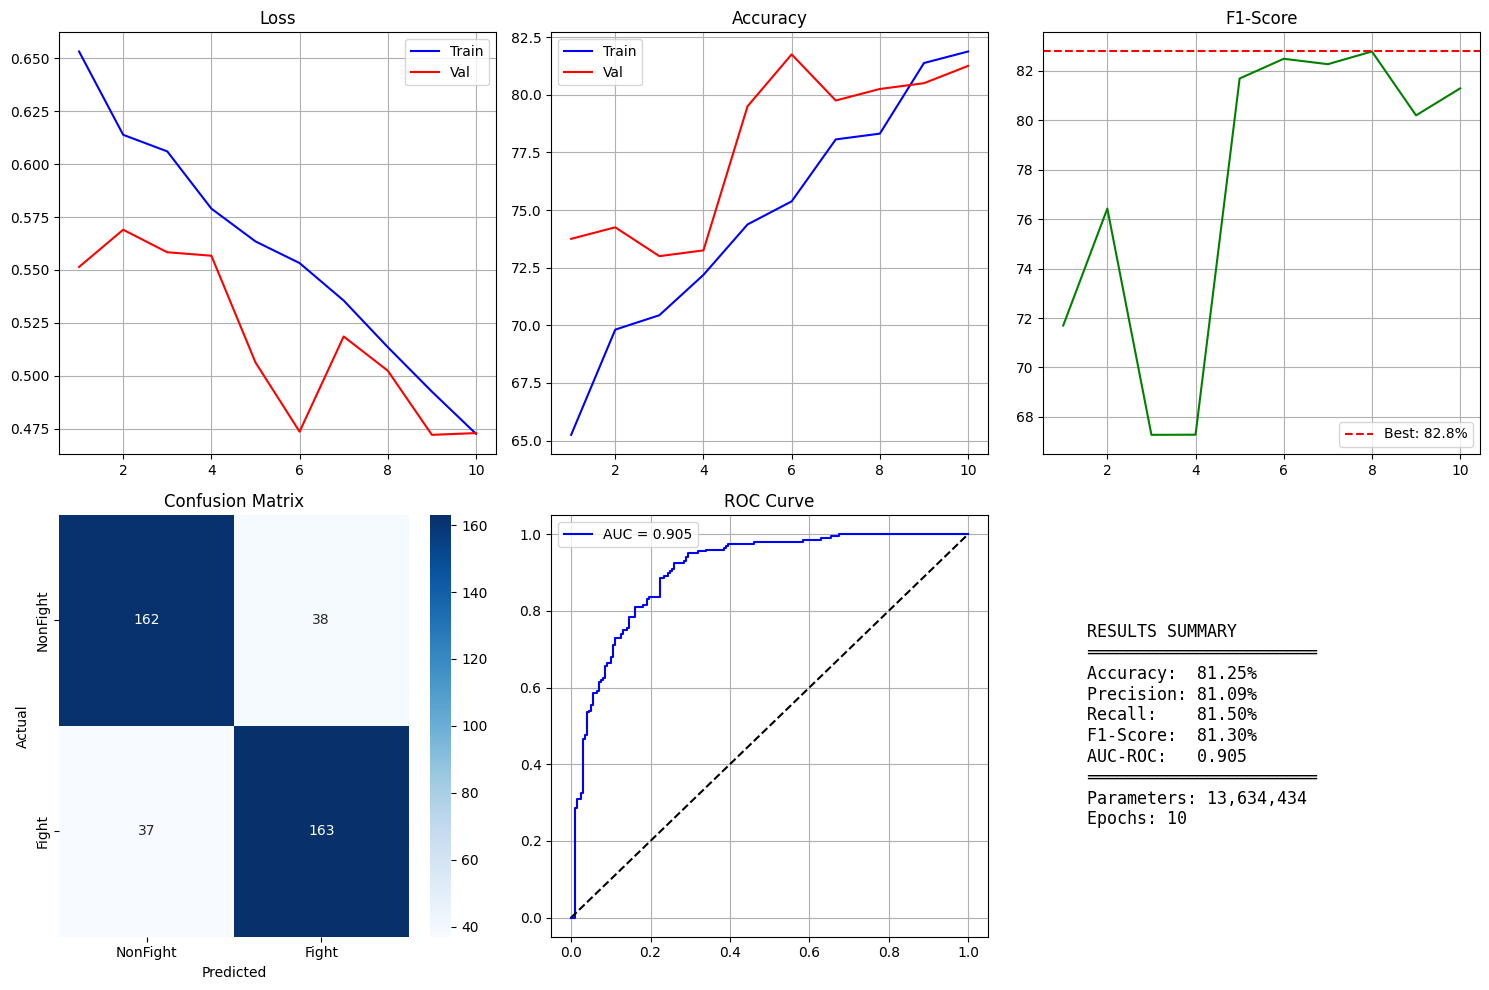

In [22]:
# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Val')
axes[0, 1].set_title('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# F1
axes[0, 2].plot(epochs_range, history['val_f1'], 'g-')
axes[0, 2].axhline(y=best_f1, color='r', linestyle='--', label=f'Best: {best_f1:.1f}%')
axes[0, 2].set_title('F1-Score')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Confusion Matrix
cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['NonFight', 'Fight'], yticklabels=['NonFight', 'Fight'])
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(final_metrics['labels'], final_metrics['probabilities'])
roc_auc = auc(fpr, tpr)
axes[1, 1].plot(fpr, tpr, 'b-', label=f'AUC = {roc_auc:.3f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Results Summary
axes[1, 2].axis('off')
summary_text = f"""
RESULTS SUMMARY
═══════════════════════
Accuracy:  {final_metrics['accuracy']:.2f}%
Precision: {final_metrics['precision']:.2f}%
Recall:    {final_metrics['recall']:.2f}%
F1-Score:  {final_metrics['f1']:.2f}%
AUC-ROC:   {roc_auc:.3f}
═══════════════════════
Parameters: {model.module.count_parameters() if USE_MULTI_GPU else model.count_parameters():,}
Epochs: {len(history['train_loss'])}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=12, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

In [23]:
# Save model
torch.save({
    'model_state_dict': best_state,
    'config': CONFIG,
    'metrics': {
        'accuracy': final_metrics['accuracy'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1'],
        'auc': roc_auc
    }
}, 'violence_detector.pth')

print("\n💾 Model saved to 'violence_detector.pth'")


💾 Model saved to 'violence_detector.pth'


In [24]:
print("\n" + "="*60)
print("✅ TRAINING COMPLETE")
print("="*60)
print(f"""
Model: 3D CNN Violence Detector
Dataset: RWF-2000
Task: Binary Classification (Fight vs NonFight)

Results:
  • Accuracy:  {final_metrics['accuracy']:.2f}%
  • Precision: {final_metrics['precision']:.2f}%
  • Recall:    {final_metrics['recall']:.2f}%
  • F1-Score:  {final_metrics['f1']:.2f}%
  • AUC-ROC:   {roc_auc:.3f}

Files Saved:
  • results.png
  • violence_detector.pth
""")


✅ TRAINING COMPLETE

Model: 3D CNN Violence Detector
Dataset: RWF-2000
Task: Binary Classification (Fight vs NonFight)

Results:
  • Accuracy:  81.25%
  • Precision: 81.09%
  • Recall:    81.50%
  • F1-Score:  81.30%
  • AUC-ROC:   0.905

Files Saved:
  • results.png
  • violence_detector.pth



In [28]:
# ===== 1. Install Hugging Face Hub =====
!pip install -q huggingface_hub

# ===== 2. Get HF token from Kaggle Secrets =====
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

from huggingface_hub import login, HfApi
login(token=HF_TOKEN)

# ===== 3. Save your model =====
import torch

torch.save({
    'model_state_dict': best_state,
    'config': CONFIG,
    'metrics': {
        'accuracy': final_metrics['accuracy'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1'],
        'auc': roc_auc
    }
}, "violence_detector.pth")

# ===== 4. Upload to Hugging Face =====
api = HfApi()
repo_id = "Anbi105/violence-detector"

api.upload_file(
    path_or_fileobj="violence_detector.pth",
    path_in_repo="violence_detector.pth",
    repo_id=repo_id,
)

print("✅ Model successfully uploaded to Hugging Face!")
print("🔗 https://huggingface.co/Anbi105/violence-detector")


ConnectionError: Connection error trying to communicate with service.